In [135]:
import utils
import numpy as np
import pandas as pd
import os
import importlib
import re
from matplotlib.pyplot import cm

importlib.reload(utils)

import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme

pd.set_option('future.no_silent_downcasting', True)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', 20)
#pd.set_option('display.width', 1000)

In [136]:
# Make output folder
output_dir = os.path.join('..','..','plots','behavioural', 'objective_performance')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [137]:
# Preparation
pilot_analysis = True
unique_subject_ids = [802,803,804,805,806,807,808,809,810,811,813,814,815]
unique_sessions = [1, 2, 3, 4]
plot_range = [0, 6]

if pilot_analysis:
    raw_output_path = '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2'
else:
    raw_output_path = '/Volumes/project/3025011.02/raw/'
recent_results = utils.analysis_functions.list_files_with_date_and_subject_id(raw_output_path, unique_subject_ids, unique_sessions)

sub-802 did not complete session-02
sub-802 did not complete session-03
sub-802 did not complete session-04
sub-803 did not complete session-02
sub-803 did not complete session-03
sub-803 did not complete session-04
sub-804 did not complete session-02
sub-804 did not complete session-03
sub-804 did not complete session-04
sub-805 did not complete session-02
sub-805 did not complete session-03
sub-805 did not complete session-04
sub-806 did not complete session-02
sub-806 did not complete session-03
sub-806 did not complete session-04
sub-807 did not complete session-02
sub-807 did not complete session-03
sub-807 did not complete session-04
sub-808 did not complete session-02
sub-808 did not complete session-03
sub-808 did not complete session-04
sub-809 did not complete session-02
sub-809 did not complete session-03
sub-809 did not complete session-04
sub-810 did not complete session-02
sub-810 did not complete session-03
sub-810 did not complete session-04
sub-811 did not complete ses

In [138]:
if not recent_results:
    raise Exception('No files found')
print(recent_results)

['/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/behavioural_output_sub-802_session-01_dummy_2024-09-10_11-06-48.csv', '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/behavioural_output_sub-803_session-01_dummy_2024-09-10_13-40-11.csv', '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/behavioural_output_sub-804_session-01_dummy_2024-09-10_15-41-26.csv', '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/behavioural_output_sub-805_session-01_dummy_2024-09-11_09-08-32.csv', '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/behavioural_output_sub-806_session-01_dummy_2024-09-11_11-12-35.csv', '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/behavioural_output_sub-807_session-01_dummy_2024-09-11_13-42-58.csv', '/Volumes

### Remove invalid files

In [139]:
# Remove files that contain invalid data
raw_output_path = '/Volumes/project/3025011.02/raw/'
invalid_data = pd.read_csv(f'{raw_output_path}../incomplete_data.csv', delimiter=';')
combinations = {
    f"sub-{row['subject-id']:03}_session-{row['session-number']:02}"
    for _, row in invalid_data[invalid_data['datatype'] == 'beh'].iterrows()
}
print(f'These participants will be excluded: {combinations}')

patterns = [re.compile(re.escape(combo)) for combo in combinations]
# Filter the list: remove any string that contains one of the combinations
recent_results = [
    item for item in recent_results
    if not any(pattern.search(item) for pattern in patterns)
]
print(recent_results)

These participants will be excluded: {'sub-003_session-03'}
['/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/behavioural_output_sub-802_session-01_dummy_2024-09-10_11-06-48.csv', '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/behavioural_output_sub-803_session-01_dummy_2024-09-10_13-40-11.csv', '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/behavioural_output_sub-804_session-01_dummy_2024-09-10_15-41-26.csv', '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/behavioural_output_sub-805_session-01_dummy_2024-09-11_09-08-32.csv', '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/behavioural_output_sub-806_session-01_dummy_2024-09-11_11-12-35.csv', '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/behavioural_output_

In [140]:
combined_results_dataframe = utils.analysis_functions.combine_result_files(recent_results)
if pilot_analysis:
    combined_results_dataframe.rename(columns={'iti': 'trial_duration'}, inplace=True)
    combined_results_dataframe['stimuli_type'] = combined_results_dataframe['stimuli_type'].replace(3, 2)
print(combined_results_dataframe)

      trial  emotional_cue_time response objectively_correct  \
0         0        1.725959e+09     down                Even   
1         1        1.725959e+09       up                Even   
2         2        1.725959e+09     down                Even   
3         3        1.725959e+09     down                Even   
4         4        1.725959e+09     down                Even   
5         5        1.725959e+09       up                Even   
6         6        1.725959e+09       up                Even   
7         7        1.725959e+09       up                Even   
8         8        1.725959e+09       up                True   
9         9        1.725959e+09       up               False   
10       10        1.725959e+09       up                True   
11       11        1.725959e+09       up               False   
12       12        1.725959e+09       up                True   
13       13        1.725959e+09       up               False   
14       14        1.725959e+09     down

# Flip results if joystick orientation was incorrect
Specifically, switch the response and probability

In [141]:
# List of subject_session combinations to update
match_list = ['sub-004_session-04']

# Create a new column that combines subject_id and session in the same format as the list.
combined_results_dataframe['sub_session'] = combined_results_dataframe['subject_id'] + '_' + combined_results_dataframe['session']

# Create a mask for rows that match any of the combinations in match_list.
mask = combined_results_dataframe['sub_session'].isin(match_list)

# For 'probability_condition', swap 80 with 20 and vice versa.
combined_results_dataframe.loc[mask, 'probability_condition'] = (
    combined_results_dataframe.loc[mask, 'probability_condition']
    .replace({80: 20, 20: 80})
)

# For 'response', swap 'up' with 'down' and vice versa.
combined_results_dataframe.loc[mask, 'response'] = (
    combined_results_dataframe.loc[mask, 'response']
    .replace({'up': 'down', 'down': 'up'})
)

# Optionally, drop the helper column
combined_results_dataframe.drop(columns='sub_session', inplace=True)

print(combined_results_dataframe)

      trial  emotional_cue_time response objectively_correct  \
0         0        1.725959e+09     down                Even   
1         1        1.725959e+09       up                Even   
2         2        1.725959e+09     down                Even   
3         3        1.725959e+09     down                Even   
4         4        1.725959e+09     down                Even   
5         5        1.725959e+09       up                Even   
6         6        1.725959e+09       up                Even   
7         7        1.725959e+09       up                Even   
8         8        1.725959e+09       up                True   
9         9        1.725959e+09       up               False   
10       10        1.725959e+09       up                True   
11       11        1.725959e+09       up               False   
12       12        1.725959e+09       up                True   
13       13        1.725959e+09       up               False   
14       14        1.725959e+09     down

# Analysis
First, we'll look at the reaction time. A plot with all the RT's and average will do.
Second we will look at the percentage of correct answers.
Lastly, we will be looking at a win-stay lose shift to see when behaviour stabilises after a shift in reward contingency.

In [142]:
# Count amount of subplots necessary based on subject_id's and sessions
## Finds unique values
unique_subject_ids = combined_results_dataframe['subject_id'].unique()
unique_sessions = combined_results_dataframe['session'].unique()

## Calculates the number of subplots needed
n_rows = len(unique_subject_ids)
n_cols = len(unique_sessions)
n_subplots = len(unique_sessions) * len(unique_subject_ids)

### Make additional columns for congruency, valence, WSLS and volatility

In [143]:
combined_results_dataframe['congruency'] = combined_results_dataframe.apply(utils.analysis_functions.check_congruency, axis=1)
print(combined_results_dataframe[['stimuli_type','probability_condition','congruency']])

      stimuli_type  probability_condition   congruency
0                1                     50    undefined
1                1                     50    undefined
2                2                     50    undefined
3                2                     50    undefined
4                2                     50    undefined
5                1                     50    undefined
6                1                     50    undefined
7                2                     50    undefined
8                1                     80    congruent
9                2                     20    congruent
10               1                     80    congruent
11               2                     20    congruent
12               1                     80    congruent
13               2                     20    congruent
14               2                     20    congruent
15               1                     80    congruent
16               1                     80    congruent
17        

In [144]:
combined_results_dataframe['valence'] = combined_results_dataframe.apply(utils.analysis_functions.check_valence, axis=1)
print(combined_results_dataframe[['stimuli_type','valence']])

      stimuli_type valence
0                1   angry
1                1   angry
2                2   happy
3                2   happy
4                2   happy
5                1   angry
6                1   angry
7                2   happy
8                1   angry
9                2   happy
10               1   angry
11               2   happy
12               1   angry
13               2   happy
14               2   happy
15               1   angry
16               1   angry
17               2   happy
18               2   happy
19               1   angry
20               2   happy
21               1   angry
22               1   angry
23               2   happy
24               1   angry
25               2   happy
26               2   happy
27               1   angry
28               1   angry
29               2   happy
30               1   angry
31               2   happy
32               1   angry
33               2   happy
34               1   angry
35               2   happy
3

In [145]:
# Turns the objective values into boolean ones
mapping = {'True': 1, 'False': 0, 'Even': 0, 'Late': 0}
#pd.options.display.max_rows = None

combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct'].replace(mapping)
combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct_boolean'].astype('int')

In [146]:
# Add WSLS columns
combined_results_dataframe = utils.learning_models.add_WSLS_column(combined_results_dataframe)

     subjectively_correct_one_back response_one_back response  WS  LS
0                              NaN               NaN     down   0   0
1                            False              down       up   0   1
2                            False                up       up   0  -1
3                            False                up       up   0  -1
4                             True                up       up   1   0
5                             True                up       up   1   0
6                            False                up       up   0  -1
7                            False                up       up   0  -1
8                             True                up       up   1   0
9                            False                up       up   0  -1
10                            True                up       up   1   0
11                           False                up       up   0  -1
12                            True                up       up   1   0
13                  

In [147]:
# Add volatility column
combined_results_dataframe = combined_results_dataframe[combined_results_dataframe['probability_condition'] != 50]
combined_results_dataframe = combined_results_dataframe.groupby('stimuli_type', group_keys=False).apply(lambda x: utils.analysis_functions.check_volatility(x))
combined_results_dataframe = combined_results_dataframe.sort_values(by=['subject_id','session','stimuli_type','trial'], ascending=[True, True, True, True])
print(combined_results_dataframe)

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5900/2827216585.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  combined_results_dataframe = combined_results_dataframe.groupby('stimuli_type', group_keys=False).apply(lambda x: utils.analysis_functions.check_volatility(x))


      trial  emotional_cue_time response objectively_correct  \
0         8        1.725959e+09       up                True   
1        10        1.725959e+09       up                True   
2        12        1.725959e+09       up                True   
3        15        1.725959e+09       up                True   
4        16        1.725959e+09       up                True   
5        19        1.725959e+09       up                True   
6        21        1.725959e+09       up               False   
7        22        1.725959e+09       up               False   
8        24        1.725959e+09       up               False   
9        27        1.725959e+09       up               False   
10       28        1.725959e+09       up               False   
11       30        1.725960e+09       up               False   
12       32        1.725960e+09       up                True   
13       34        1.725960e+09       up                True   
14       38        1.725960e+09       up

# Win-stay plots

In [148]:
# Filter out the trials where there was no win-stay or win-shift
combined_results_dataframe_WS = combined_results_dataframe[combined_results_dataframe['WS'] != 0]
# Replace -1 by 0's
combined_results_dataframe_WS['WS'] = combined_results_dataframe_WS['WS'].replace(-1, 0)

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5900/2651846892.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_dataframe_WS['WS'] = combined_results_dataframe_WS['WS'].replace(-1, 0)


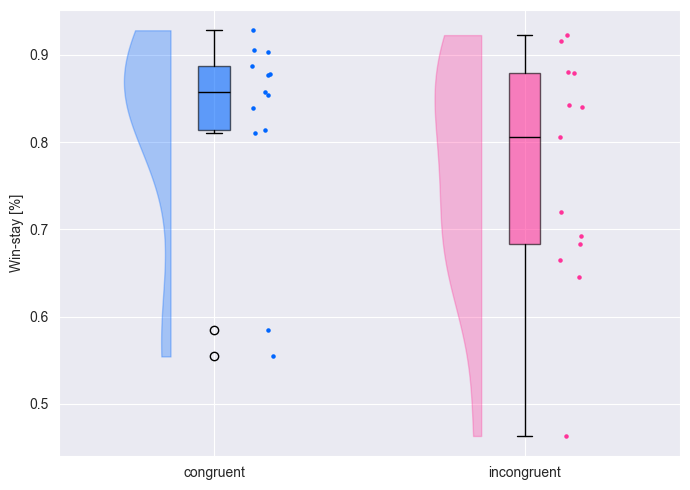

In [149]:
# Comparing overall congruency performance difference
dataframe_1 = combined_results_dataframe_WS[combined_results_dataframe_WS['congruency'] == 'congruent']
dataframe_1 = dataframe_1.groupby(['subject_id', 'session'])['WS'].mean().reset_index()
list_1 = dataframe_1['WS'].dropna().tolist()
dataframe_2 = combined_results_dataframe_WS[combined_results_dataframe_WS['congruency'] == 'incongruent']
dataframe_2 = dataframe_2.groupby(['subject_id', 'session'])['WS'].mean().reset_index()
list_2 = dataframe_2['WS'].dropna().tolist()
combined_list = [list_1, list_2]

# Create empty plot
fig, ax = plt.subplots(figsize=(7, 5))

# Create a list of colors
plot_colors = ['#0066ff', '#ff3399']
c = 'black'

# Boxplot data
bp = ax.boxplot(combined_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(combined_list, points=500, positions=[0.86, 1.86], widths=0.3,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(combined_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=5, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,3,1), ['congruent', 'incongruent'])  # Set text labels.
plt.ylabel('Win-stay [%]')
plot_name = 'all_trials_win-stay_congruency'

# Save and show plot
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

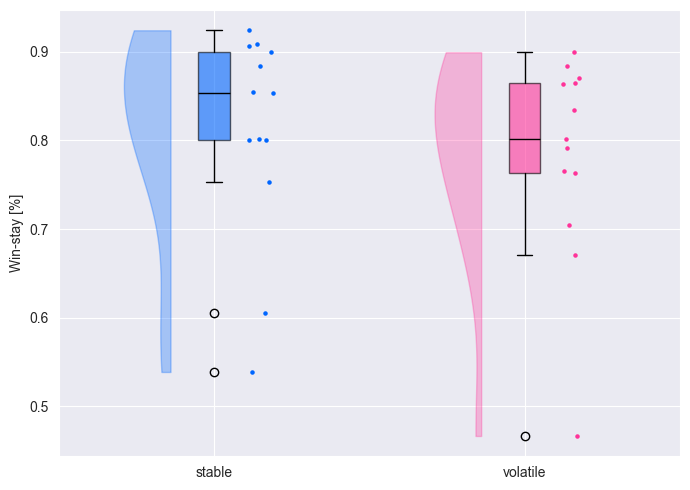

In [150]:
# Comparing overall congruency performance difference
dataframe_1 = combined_results_dataframe_WS[combined_results_dataframe_WS['volatility'] == 'stable']
dataframe_1 = dataframe_1.groupby(['subject_id', 'session'])['WS'].mean().reset_index()
list_1 = dataframe_1['WS'].dropna().tolist()
dataframe_2 = combined_results_dataframe_WS[combined_results_dataframe_WS['volatility'] == 'volatile']
dataframe_2 = dataframe_2.groupby(['subject_id', 'session'])['WS'].mean().reset_index()
list_2 = dataframe_2['WS'].dropna().tolist()
combined_list = [list_1, list_2]

# Create empty plot
fig, ax = plt.subplots(figsize=(7, 5))

# Create a list of colors
plot_colors = ['#0066ff', '#ff3399']
c = 'black'

# Boxplot data
bp = ax.boxplot(combined_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)

vp = ax.violinplot(combined_list, points=500, positions=[0.86, 1.86], widths=0.3,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(combined_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=5, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,3,1), ['stable', 'volatile'])  # Set text labels.
plt.ylabel('Win-stay [%]')
plot_name = 'all_trials_win-stay_volatility'

# Save and show plot
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

# Lose-shift plots

In [151]:
# Filter out the trials where there was no win-stay or win-shift
combined_results_dataframe_LS = combined_results_dataframe[combined_results_dataframe['LS'] != 0]
# Replace -1 by 0's
combined_results_dataframe_LS['LS'] = combined_results_dataframe_LS['LS'].replace(-1, 0)

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5900/2587669294.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_dataframe_LS['LS'] = combined_results_dataframe_LS['LS'].replace(-1, 0)


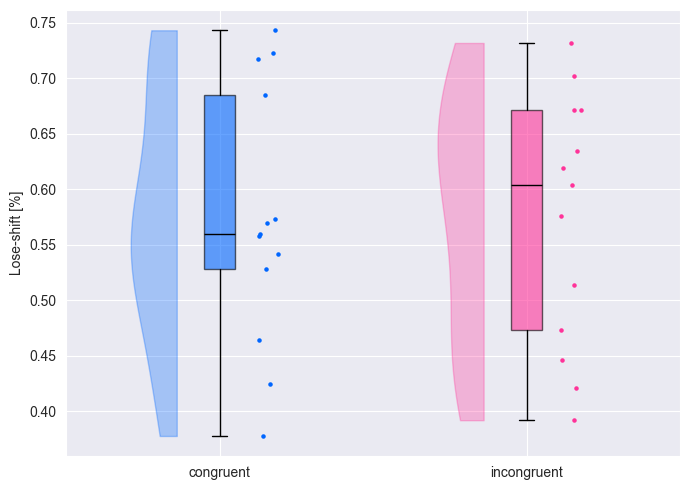

In [152]:
# Comparing overall congruency performance difference
dataframe_1 = combined_results_dataframe_LS[combined_results_dataframe_LS['congruency'] == 'congruent']
dataframe_1 = dataframe_1.groupby(['subject_id', 'session'])['LS'].mean().reset_index()
list_1 = dataframe_1['LS'].dropna().tolist()
dataframe_2 = combined_results_dataframe_LS[combined_results_dataframe_LS['congruency'] == 'incongruent']
dataframe_2 = dataframe_2.groupby(['subject_id', 'session'])['LS'].mean().reset_index()
list_2 = dataframe_2['LS'].dropna().tolist()
combined_list = [list_1, list_2]

# Create empty plot
fig, ax = plt.subplots(figsize=(7, 5))

# Create a list of colors
plot_colors = ['#0066ff', '#ff3399']
c = 'black'

# Boxplot data
bp = ax.boxplot(combined_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(combined_list, points=500, positions=[0.86, 1.86], widths=0.3,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(combined_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=5, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,3,1), ['congruent', 'incongruent'])  # Set text labels.
plt.ylabel('Lose-shift [%]')
plot_name = 'all_trials_lose-shift_congruency'

# Save and show plot
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

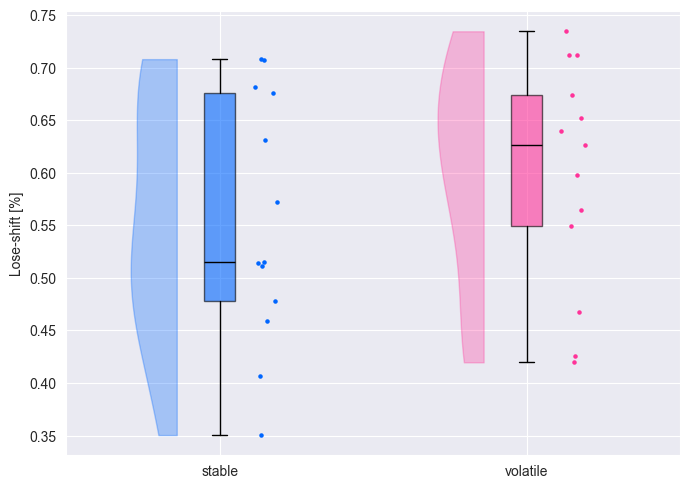

In [153]:
# Comparing overall congruency performance difference
dataframe_1 = combined_results_dataframe_LS[combined_results_dataframe_LS['volatility'] == 'stable']
dataframe_1 = dataframe_1.groupby(['subject_id', 'session'])['LS'].mean().reset_index()
list_1 = dataframe_1['LS'].dropna().tolist()
dataframe_2 = combined_results_dataframe_LS[combined_results_dataframe_LS['volatility'] == 'volatile']
dataframe_2 = dataframe_2.groupby(['subject_id', 'session'])['LS'].mean().reset_index()
list_2 = dataframe_2['LS'].dropna().tolist()
combined_list = [list_1, list_2]

# Create empty plot
fig, ax = plt.subplots(figsize=(7, 5))

# Create a list of colors
plot_colors = ['#0066ff', '#ff3399']
c = 'black'

# Boxplot data
bp = ax.boxplot(combined_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)

vp = ax.violinplot(combined_list, points=500, positions=[0.86, 1.86], widths=0.3,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(combined_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=5, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,3,1), ['stable', 'volatile'])  # Set text labels.
plt.ylabel('Lose-shift [%]')
plot_name = 'all_trials_lose-shift_volatility'

# Save and show plot
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()